# 4단계: 모델 평가 및 시각화

## 목표
- 추천 모델 정량적 평가 (Precision@K, Recall@K, NDCG@K)
- 다양한 시나리오별 성능 분석
- 결과 시각화
- 오류 분석 및 개선점 도출

In [14]:
# 필수 라이브러리 임포트
import pandas as pd
import numpy as np
import pickle
import json
from collections import Counter, defaultdict
from typing import List, Dict, Set, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

print("라이브러리 로딩 완료")

라이브러리 로딩 완료


## 4.1 모델 및 데이터 로딩

In [15]:
# 모델 로딩
PROCESSED_DIR = '../data/processed'
MODEL_PATH = f'{PROCESSED_DIR}/gapfilling_model.pkl'

with open(MODEL_PATH, 'rb') as f:
    model_data = pickle.load(f)

print(f"모델 버전: {model_data.get('version', 'unknown')}")
print(f"레시피 수: {len(model_data['recipe_ingredient_sets']):,}")
print(f"재료 수: {len(model_data['ingredient_to_recipes']):,}")

모델 버전: 1.0.0
레시피 수: 23,191
재료 수: 9,147


In [16]:
# 모델 클래스 재정의 (v2.0 - 메인 재료 가중치, 제외 재료 등 적용)
class RecipeGapFillingModel:
    """GapFilling 모델 v2.0 (평가용)"""
    
    VERSION = '2.0.0'
    
    EXCLUDE_KEYWORDS = [
        '보관법', '보관방법', '보관하는', '손질법', '손질방법', '다듬기',
        '세척법', '씻는법', '해동', '냉동보관', '냉장보관',
        '고르는법', '고르는방법', '선별법',
        '효능', '효과', '칼로리', '만들기 전', '준비하기'
    ]
    
    EXCLUDE_INGREDIENTS = {
        '물', '냉수', '찬물', '뜨거운물', '끓는물', '미지근한물',
        '소금', '설탕', '후추', '후춧가루', '흑후추',
        '식용유', '기름', '포도씨유', '카놀라유',
        '간장', '진간장', '국간장', '양조간장',
        '고춧가루', '고추장', '된장', '참기름', '들기름',
        '식초', '맛술', '청주', '미림', '다진마늘', '다진파', '생강가루',
        '얼음', '육수', '멸치육수', '다시마육수', '채수',
        '밥', '찬밥', '따뜻한밥',
    }
    
    MAIN_INGREDIENTS = {
        '소고기', '돼지고기', '닭고기', '오리고기', '양고기',
        '삼겹살', '목살', '안심', '등심', '갈비', '차돌박이',
        '닭가슴살', '닭다리', '닭날개', '통닭', '베이컨', '햄', '소시지',
        '생선', '연어', '고등어', '갈치', '조기', '광어', '참치',
        '오징어', '문어', '낙지', '새우', '게', '꽃게', '조개', '바지락',
        '참치캔', '고등어통조림', '연어통조림',
        '배추', '무', '감자', '고구마', '당근', '양배추', '두부',
        '버섯', '표고버섯', '양송이버섯', '느타리버섯',
        '떡', '떡국떡', '가래떡', '떡볶이떡',
        '면', '국수', '소면', '우동면', '스파게티면',
    }
    
    INGREDIENT_TO_PRODUCT_MAP = {
        '참치액': '참치캔', '멸치액젓': '멸치', '새우젓': '새우',
        '멸치육수': '멸치', '다시마육수': '다시마', '치킨스톡': '닭고기',
        '계란물': '계란', '마늘가루': '마늘', '양파가루': '양파',
    }
    
    def __init__(self, recipe_ingredient_sets, ingredient_to_recipes, recipe_metadata, synonym_dict):
        self.recipe_ingredient_sets = recipe_ingredient_sets
        self.ingredient_to_recipes = ingredient_to_recipes
        self.recipe_metadata = recipe_metadata
        self.synonym_dict = synonym_dict
        
        self.synonym_to_standard = {}
        for standard, synonyms in synonym_dict.items():
            for syn in synonyms:
                self.synonym_to_standard[syn] = standard
        
        self.params = {
            'min_match_ratio': 0.3,
            'max_gap_count': 5,
            'popularity_weight': 0.4,
            'match_weight': 0.4,
            'gap_penalty_weight': 0.2,
            'main_ingredient_bonus': 0.3,
            'min_ingredients': 3,
            'min_view_count': 500,  # ★ 인기 레시피만 (500 이상)
        }
        
        self.valid_recipe_ids = self._filter_valid_recipes()
        self._max_popularity = max(
            (m.get('popularity_score', 0) or 0 for m in recipe_metadata.values()),
            default=1
        )
    
    def _filter_valid_recipes(self):
        valid_ids = set()
        for recipe_id, ingredients in self.recipe_ingredient_sets.items():
            metadata = self.recipe_metadata.get(recipe_id, {})
            title = metadata.get('title', '') or metadata.get('name', '')
            view_count = metadata.get('view_count', 0) or 0
            
            if len(ingredients) < self.params['min_ingredients']:
                continue
            if any(kw in title for kw in self.EXCLUDE_KEYWORDS):
                continue
            if view_count < self.params['min_view_count']:
                continue
            valid_ids.add(recipe_id)
        
        print(f"유효 레시피: {len(valid_ids):,}개 / {len(self.recipe_ingredient_sets):,}개")
        return valid_ids
    
    def normalize_ingredient(self, name):
        if not name:
            return name
        name = str(name).strip()
        if name in self.synonym_to_standard:
            return self.synonym_to_standard[name]
        for standard in self.synonym_dict.keys():
            if standard in name:
                return standard
        return name
    
    def map_to_product(self, ingredient):
        return self.INGREDIENT_TO_PRODUCT_MAP.get(ingredient, ingredient)
    
    def is_main_ingredient(self, ingredient):
        return ingredient in self.MAIN_INGREDIENTS
    
    def should_exclude(self, ingredient):
        return ingredient in self.EXCLUDE_INGREDIENTS
    
    def get_ingredient_weight(self, ingredient):
        if self.should_exclude(ingredient):
            return 0.0
        if self.is_main_ingredient(ingredient):
            return 1.5
        return 1.0
    
    def find_candidate_recipes(self, cart_ingredients):
        candidates = set()
        for ingredient in cart_ingredients:
            normalized = self.normalize_ingredient(ingredient)
            if normalized in self.ingredient_to_recipes:
                for recipe_id in self.ingredient_to_recipes[normalized]:
                    if recipe_id in self.valid_recipe_ids:
                        candidates.add(recipe_id)
        return candidates
    
    def recommend(self, cart_ingredients, top_k=10, min_match_ratio=None, max_gap_count=None):
        if min_match_ratio is None:
            min_match_ratio = self.params['min_match_ratio']
        if max_gap_count is None:
            max_gap_count = self.params['max_gap_count']
        
        cart_set = set(self.normalize_ingredient(ing) for ing in cart_ingredients)
        candidates = self.find_candidate_recipes(cart_ingredients)
        
        if not candidates:
            return []
        
        results = []
        for recipe_id in candidates:
            recipe_ingredients = self.recipe_ingredient_sets.get(recipe_id, set())
            if not recipe_ingredients:
                continue
            
            matched = cart_set & recipe_ingredients
            gaps = recipe_ingredients - cart_set
            
            # Gap 필터링 및 상품 매핑
            filtered_gaps = [g for g in gaps if not self.should_exclude(g)]
            mapped_gaps = list(dict.fromkeys([self.map_to_product(g) for g in filtered_gaps]))
            
            match_ratio = len(matched) / len(recipe_ingredients)
            
            if match_ratio < min_match_ratio:
                continue
            if len(mapped_gaps) > max_gap_count:
                continue
            
            metadata = self.recipe_metadata.get(recipe_id, {})
            
            # 메인 재료 보너스
            main_matched = sum(1 for m in matched if self.is_main_ingredient(m))
            main_bonus = main_matched * self.params['main_ingredient_bonus'] / max(len(recipe_ingredients), 1)
            
            # 인기도
            popularity = metadata.get('popularity_score', 0) or 0
            norm_popularity = popularity / self._max_popularity if self._max_popularity > 0 else 0
            
            # Gap 패널티
            gap_weighted = sum(self.get_ingredient_weight(g) for g in filtered_gaps)
            gap_penalty = min(gap_weighted / (self.params['max_gap_count'] * 1.5), 1.0)
            
            # 최종 점수
            final_score = (
                self.params['match_weight'] * match_ratio +
                self.params['popularity_weight'] * norm_popularity +
                main_bonus -
                self.params['gap_penalty_weight'] * gap_penalty
            )
            final_score = max(0, min(1, final_score))
            
            results.append({
                'recipe_id': recipe_id,
                'name': metadata.get('name', ''),           # ★ 요리명
                'title': metadata.get('title', ''),
                'matched_ingredients': list(matched),
                'gap_ingredients': mapped_gaps,
                'match_ratio': match_ratio,
                'gap_count': len(mapped_gaps),
                'total_ingredients': len(recipe_ingredients),
                'popularity_score': popularity,
                'view_count': metadata.get('view_count', 0),
                'final_score': final_score,
                'category': metadata.get('category', ''),
                'difficulty': metadata.get('difficulty', '')
            })
        
        results.sort(key=lambda x: x['final_score'], reverse=True)
        return results[:top_k]

# 모델 인스턴스 생성
model = RecipeGapFillingModel(
    recipe_ingredient_sets=model_data['recipe_ingredient_sets'],
    ingredient_to_recipes=model_data['ingredient_to_recipes'],
    recipe_metadata=model_data['recipe_metadata'],
    synonym_dict=model_data['synonym_dict']
)

print(f"모델 v{model.VERSION} 로딩 완료")
print(f"  - 유효 레시피: {len(model.valid_recipe_ids):,}개")
print(f"  - 메인 재료: {len(model.MAIN_INGREDIENTS)}개")
print(f"  - 제외 재료: {len(model.EXCLUDE_INGREDIENTS)}개")

유효 레시피: 9,174개 / 23,191개
모델 v2.0.0 로딩 완료
  - 유효 레시피: 9,174개
  - 메인 재료: 56개
  - 제외 재료: 39개


## 4.2 평가 메트릭 정의

In [17]:
class RecommendationEvaluator:
    """
    추천 시스템 평가 클래스
    
    평가 메트릭:
    - Precision@K: 추천된 K개 중 관련 있는 아이템 비율
    - Recall@K: 전체 관련 아이템 중 추천된 비율
    - NDCG@K: 순위를 고려한 관련성 점수
    - Coverage: 추천 가능한 레시피 비율
    - Gap Accuracy: Gap 재료 추천 정확도
    """
    
    @staticmethod
    def precision_at_k(recommended: List, relevant: Set, k: int) -> float:
        """
        Precision@K 계산
        
        Args:
            recommended: 추천된 아이템 리스트
            relevant: 관련 있는 아이템 집합
            k: 상위 K개
        
        Returns:
            float: Precision@K (0-1)
        """
        if k == 0:
            return 0.0
        
        recommended_k = recommended[:k]
        hits = sum(1 for item in recommended_k if item in relevant)
        return hits / k
    
    @staticmethod
    def recall_at_k(recommended: List, relevant: Set, k: int) -> float:
        """
        Recall@K 계산
        
        Args:
            recommended: 추천된 아이템 리스트
            relevant: 관련 있는 아이템 집합
            k: 상위 K개
        
        Returns:
            float: Recall@K (0-1)
        """
        if len(relevant) == 0:
            return 0.0
        
        recommended_k = recommended[:k]
        hits = sum(1 for item in recommended_k if item in relevant)
        return hits / len(relevant)
    
    @staticmethod
    def dcg_at_k(relevances: List[float], k: int) -> float:
        """
        DCG@K (Discounted Cumulative Gain) 계산
        
        Args:
            relevances: 각 아이템의 관련성 점수 리스트
            k: 상위 K개
        
        Returns:
            float: DCG@K
        """
        relevances_k = relevances[:k]
        dcg = 0.0
        for i, rel in enumerate(relevances_k):
            dcg += rel / np.log2(i + 2)  # i+2 because index starts from 0
        return dcg
    
    @staticmethod
    def ndcg_at_k(recommended_relevances: List[float], ideal_relevances: List[float], k: int) -> float:
        """
        NDCG@K (Normalized DCG) 계산
        
        Args:
            recommended_relevances: 추천 순서대로의 관련성 점수
            ideal_relevances: 이상적인 순서의 관련성 점수
            k: 상위 K개
        
        Returns:
            float: NDCG@K (0-1)
        """
        dcg = RecommendationEvaluator.dcg_at_k(recommended_relevances, k)
        idcg = RecommendationEvaluator.dcg_at_k(sorted(ideal_relevances, reverse=True), k)
        
        if idcg == 0:
            return 0.0
        return dcg / idcg
    
    @staticmethod
    def coverage(recommended_items: Set, total_items: int) -> float:
        """
        Coverage 계산 (추천된 고유 아이템 비율)
        
        Args:
            recommended_items: 추천된 고유 아이템 집합
            total_items: 전체 아이템 수
        
        Returns:
            float: Coverage (0-1)
        """
        if total_items == 0:
            return 0.0
        return len(recommended_items) / total_items

evaluator = RecommendationEvaluator()
print("평가 메트릭 클래스 정의 완료")

평가 메트릭 클래스 정의 완료


## 4.3 테스트 데이터셋 생성

In [18]:
def generate_test_cases(model, n_cases=100):
    """
    레시피에서 일부 재료를 추출하여 테스트 케이스 생성
    
    방법: 실제 레시피에서 60-80%의 재료를 장바구니로 사용,
          나머지 재료가 Gap (정답)
    """
    test_cases = []
    
    # ★ 유효한 레시피에서만 테스트 케이스 생성 (재료 5개 이상)
    valid_recipes = [
        (rid, ingredients) 
        for rid, ingredients in model.recipe_ingredient_sets.items()
        if rid in model.valid_recipe_ids and len(ingredients) >= 5
    ]
    
    print(f"테스트 대상 레시피: {len(valid_recipes):,}개 (유효 레시피 중 재료 5개 이상)")
    
    sampled = random.sample(valid_recipes, min(n_cases, len(valid_recipes)))
    
    for recipe_id, ingredients in sampled:
        ingredients_list = list(ingredients)
        n_ingredients = len(ingredients_list)
        
        n_cart = int(n_ingredients * random.uniform(0.6, 0.8))
        n_cart = max(2, n_cart)
        
        cart = random.sample(ingredients_list, n_cart)
        gaps = set(ingredients_list) - set(cart)
        
        # ★ Gap에서 제외 재료 필터링
        filtered_gaps = [g for g in gaps if not model.should_exclude(g)]
        
        metadata = model.recipe_metadata.get(recipe_id, {})
        
        test_cases.append({
            'recipe_id': recipe_id,
            'recipe_name': metadata.get('name', ''),       # ★ 요리명
            'recipe_title': metadata.get('title', ''),
            'cart': cart,
            'ground_truth_gaps': filtered_gaps,             # ★ 필터링된 Gap
            'total_ingredients': n_ingredients,
            'category': metadata.get('category', '')
        })
    
    return test_cases

# 테스트 케이스 생성
test_cases = generate_test_cases(model, n_cases=200)
print(f"생성된 테스트 케이스: {len(test_cases)}개")

# 샘플 확인 (요리명 vs 제목)
sample_case = test_cases[0]
print(f"\n샘플 테스트 케이스:")
print(f"  ★ 요리명: {sample_case['recipe_name']}")
print(f"  제목: {sample_case['recipe_title'][:40]}...")
print(f"  장바구니: {sample_case['cart'][:5]}..." if len(sample_case['cart']) > 5 else f"  장바구니: {sample_case['cart']}")
print(f"  정답 Gap: {sample_case['ground_truth_gaps']}")

테스트 대상 레시피: 8,340개 (유효 레시피 중 재료 5개 이상)
생성된 테스트 케이스: 200개

샘플 테스트 케이스:
  ★ 요리명: 쪽파겉절이
  제목: 5분컷 간단 쪽파김치 담그는법 쪽파겉절이 만들기...
  장바구니: ['마늘', '매실액', '통깨', '대파', '고춧가루']...
  정답 Gap: []


## 4.4 모델 평가 실행

In [19]:
def evaluate_model(model, test_cases, k_values=[1, 3, 5, 10]):
    """
    모델 종합 평가
    
    Args:
        model: GapFilling 모델
        test_cases: 테스트 케이스 리스트
        k_values: 평가할 K 값들
    
    Returns:
        Dict: 평가 결과
    """
    results = {k: {'precision': [], 'recall': [], 'ndcg': [], 'hit_rate': []} for k in k_values}
    gap_accuracy = []
    all_recommended_recipes = set()
    all_recommended_gaps = set()
    
    for case in test_cases:
        cart = case['cart']
        ground_truth_gaps = set(case['ground_truth_gaps'])
        target_recipe_id = case['recipe_id']
        
        # 추천 실행
        recommendations = model.recommend(cart, top_k=max(k_values))
        
        if not recommendations:
            continue
        
        # 추천된 레시피 ID 리스트
        recommended_ids = [r['recipe_id'] for r in recommendations]
        
        # 추천된 Gap 재료 집합
        recommended_gaps = set()
        for r in recommendations[:5]:  # 상위 5개 레시피에서 Gap 추출
            recommended_gaps.update(r['gap_ingredients'])
        
        all_recommended_recipes.update(recommended_ids)
        all_recommended_gaps.update(recommended_gaps)
        
        # Gap 정확도 (정답 Gap과 추천된 Gap의 교집합)
        if ground_truth_gaps:
            gap_hits = len(ground_truth_gaps & recommended_gaps)
            gap_accuracy.append(gap_hits / len(ground_truth_gaps))
        
        # K별 평가
        for k in k_values:
            # 관련 레시피 집합 (원본 레시피 포함)
            relevant = {target_recipe_id}
            
            # Precision@K
            precision = evaluator.precision_at_k(recommended_ids, relevant, k)
            results[k]['precision'].append(precision)
            
            # Hit Rate (상위 K개에 정답 레시피 포함 여부)
            hit = 1 if target_recipe_id in recommended_ids[:k] else 0
            results[k]['hit_rate'].append(hit)
            
            # NDCG@K (매칭 비율을 관련성 점수로 사용)
            relevances = [r['match_ratio'] for r in recommendations[:k]]
            ideal_relevances = sorted(relevances, reverse=True)
            ndcg = evaluator.ndcg_at_k(relevances, ideal_relevances, k)
            results[k]['ndcg'].append(ndcg)
    
    # 결과 집계
    summary = {}
    for k in k_values:
        summary[f'Precision@{k}'] = np.mean(results[k]['precision'])
        summary[f'Hit_Rate@{k}'] = np.mean(results[k]['hit_rate'])
        summary[f'NDCG@{k}'] = np.mean(results[k]['ndcg'])
    
    summary['Gap_Accuracy'] = np.mean(gap_accuracy) if gap_accuracy else 0
    summary['Recipe_Coverage'] = len(all_recommended_recipes) / len(model.recipe_ingredient_sets)
    summary['Gap_Ingredient_Coverage'] = len(all_recommended_gaps) / len(model.ingredient_to_recipes)
    
    return summary, results

# 평가 실행
print("모델 평가 실행 중...")
summary, detailed_results = evaluate_model(model, test_cases)

print("\n" + "=" * 60)
print("모델 평가 결과")
print("=" * 60)
for metric, value in summary.items():
    print(f"{metric}: {value:.4f}")

모델 평가 실행 중...

모델 평가 결과
Precision@1: 0.1650
Hit_Rate@1: 0.1650
NDCG@1: 1.0000
Precision@3: 0.0983
Hit_Rate@3: 0.2950
NDCG@3: 0.9598
Precision@5: 0.0780
Hit_Rate@5: 0.3900
NDCG@5: 0.9514
Precision@10: 0.0575
Hit_Rate@10: 0.5750
NDCG@10: 0.9496
Gap_Accuracy: 0.4605
Recipe_Coverage: 0.0352
Gap_Ingredient_Coverage: 0.0281


## 4.5 평가 결과 시각화

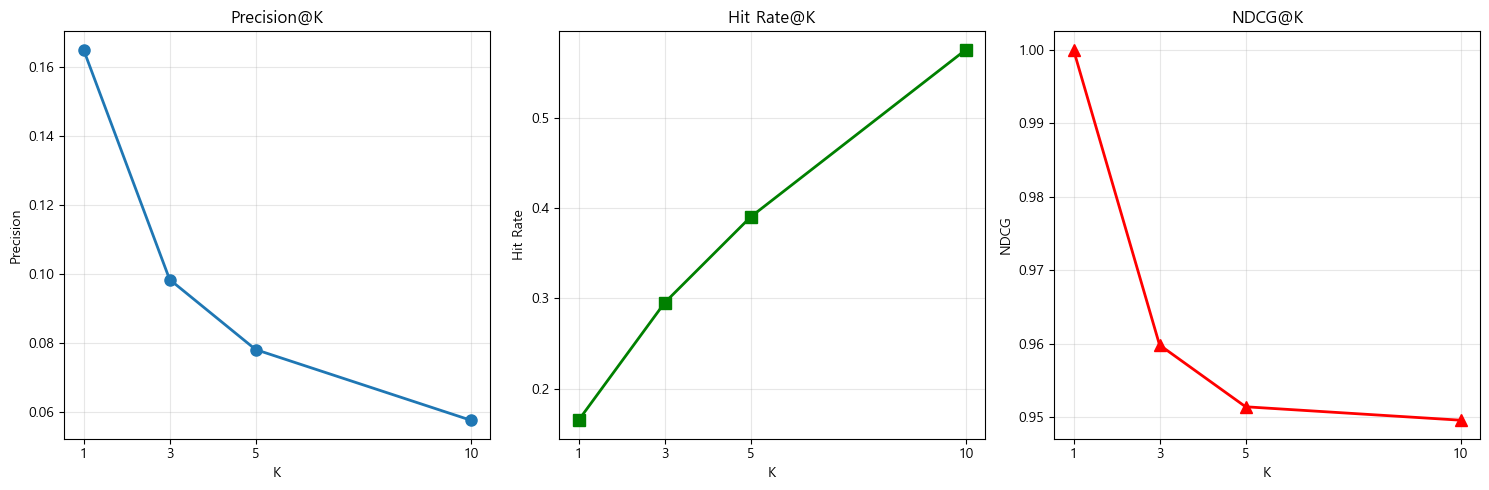

그래프 저장: ../data/processed/evaluation_metrics.png


In [20]:
# K에 따른 메트릭 변화 시각화
k_values = [1, 3, 5, 10]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Precision@K
precisions = [summary[f'Precision@{k}'] for k in k_values]
axes[0].plot(k_values, precisions, marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision@K')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_values)

# Hit Rate@K
hit_rates = [summary[f'Hit_Rate@{k}'] for k in k_values]
axes[1].plot(k_values, hit_rates, marker='s', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Hit Rate')
axes[1].set_title('Hit Rate@K')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_values)

# NDCG@K
ndcgs = [summary[f'NDCG@{k}'] for k in k_values]
axes[2].plot(k_values, ndcgs, marker='^', linewidth=2, markersize=8, color='red')
axes[2].set_xlabel('K')
axes[2].set_ylabel('NDCG')
axes[2].set_title('NDCG@K')
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(k_values)

plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"그래프 저장: {PROCESSED_DIR}/evaluation_metrics.png")

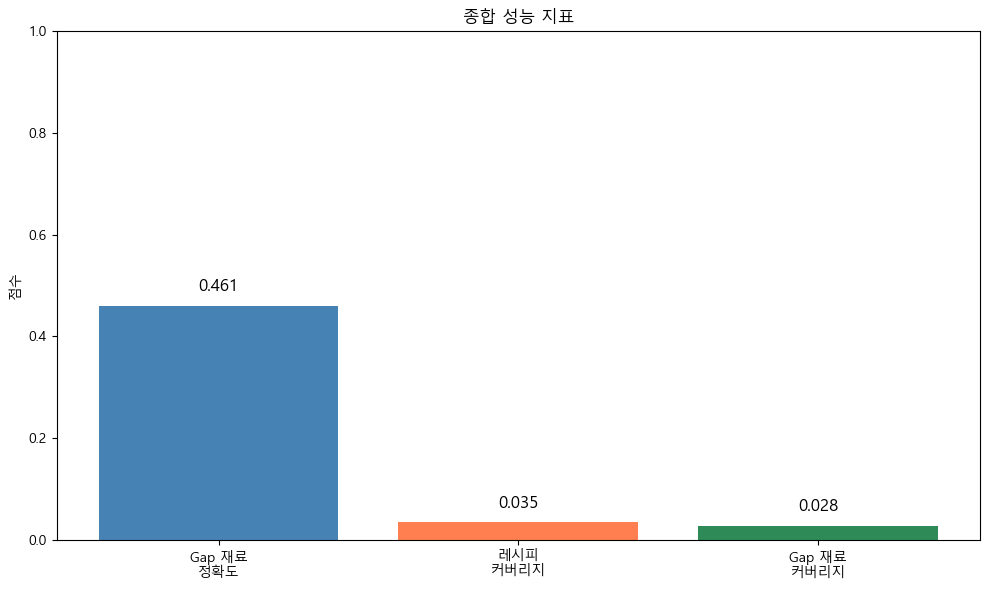

In [21]:
# 종합 성능 지표 막대 그래프
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Gap_Accuracy', 'Recipe_Coverage', 'Gap_Ingredient_Coverage']
values = [summary[m] for m in metrics]
labels = ['Gap 재료\n정확도', '레시피\n커버리지', 'Gap 재료\n커버리지']

bars = ax.bar(labels, values, color=['steelblue', 'coral', 'seagreen'])
ax.set_ylabel('점수')
ax.set_title('종합 성능 지표')
ax.set_ylim(0, 1)

# 값 표시
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

## 4.6 시나리오별 분석

In [22]:
# 장바구니 크기별 성능 분석
def analyze_by_cart_size(model, test_cases):
    """
    장바구니 크기별 성능 분석
    """
    size_groups = {'소형(2-3)': [], '중형(4-5)': [], '대형(6+)': []}
    
    for case in test_cases:
        cart_size = len(case['cart'])
        
        if cart_size <= 3:
            group = '소형(2-3)'
        elif cart_size <= 5:
            group = '중형(4-5)'
        else:
            group = '대형(6+)'
        
        recommendations = model.recommend(case['cart'], top_k=5)
        
        if recommendations:
            # 정답 레시피가 상위 5개에 포함되는지
            hit = 1 if case['recipe_id'] in [r['recipe_id'] for r in recommendations] else 0
            avg_match_ratio = np.mean([r['match_ratio'] for r in recommendations])
        else:
            hit = 0
            avg_match_ratio = 0
        
        size_groups[group].append({
            'hit': hit,
            'match_ratio': avg_match_ratio
        })
    
    results = {}
    for group, data in size_groups.items():
        if data:
            results[group] = {
                'count': len(data),
                'hit_rate': np.mean([d['hit'] for d in data]),
                'avg_match_ratio': np.mean([d['match_ratio'] for d in data])
            }
    
    return results

size_analysis = analyze_by_cart_size(model, test_cases)

print("장바구니 크기별 성능:")
print("=" * 50)
for group, stats in size_analysis.items():
    print(f"\n{group}:")
    print(f"  테스트 케이스 수: {stats['count']}")
    print(f"  Hit Rate@5: {stats['hit_rate']:.4f}")
    print(f"  평균 매칭 비율: {stats['avg_match_ratio']:.4f}")

장바구니 크기별 성능:

소형(2-3):
  테스트 케이스 수: 23
  Hit Rate@5: 0.6087
  평균 매칭 비율: 0.4978

중형(4-5):
  테스트 케이스 수: 69
  Hit Rate@5: 0.4493
  평균 매칭 비율: 0.5411

대형(6+):
  테스트 케이스 수: 108
  Hit Rate@5: 0.3056
  평균 매칭 비율: 0.5958


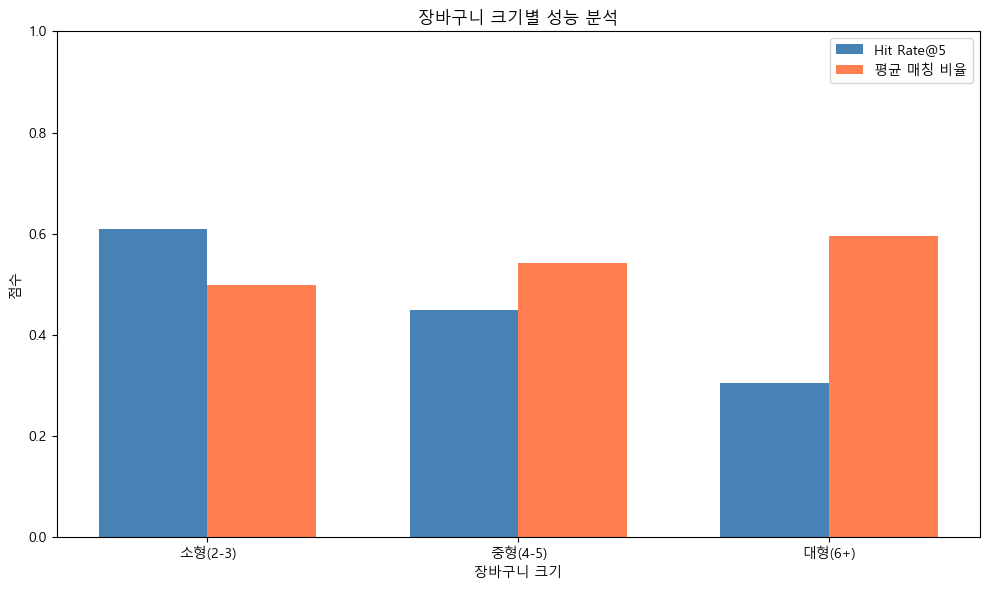

In [23]:
# 장바구니 크기별 성능 시각화
groups = list(size_analysis.keys())
hit_rates = [size_analysis[g]['hit_rate'] for g in groups]
match_ratios = [size_analysis[g]['avg_match_ratio'] for g in groups]

x = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, hit_rates, width, label='Hit Rate@5', color='steelblue')
bars2 = ax.bar(x + width/2, match_ratios, width, label='평균 매칭 비율', color='coral')

ax.set_xlabel('장바구니 크기')
ax.set_ylabel('점수')
ax.set_title('장바구니 크기별 성능 분석')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 4.7 오류 분석

In [24]:
# 실패 케이스 분석
def analyze_failures(model, test_cases, top_k=5):
    """
    추천 실패 케이스 분석
    """
    failures = []
    
    for case in test_cases:
        recommendations = model.recommend(case['cart'], top_k=top_k)
        
        if not recommendations:
            failures.append({
                'type': 'no_recommendation',
                'case': case,
                'reason': '추천 결과 없음'
            })
            continue
        
        recommended_ids = [r['recipe_id'] for r in recommendations]
        if case['recipe_id'] not in recommended_ids:
            # 왜 실패했는지 분석
            cart_set = set(model.normalize_ingredient(ing) for ing in case['cart'])
            recipe_ingredients = model.recipe_ingredient_sets.get(case['recipe_id'], set())
            match_ratio = len(cart_set & recipe_ingredients) / len(recipe_ingredients) if recipe_ingredients else 0
            
            failures.append({
                'type': 'not_in_top_k',
                'case': case,
                'actual_match_ratio': match_ratio,
                'top_1_score': recommendations[0]['final_score'],
                'reason': f'매칭 비율 {match_ratio:.2f}이 상위 {top_k}개에 못 미침'
            })
    
    return failures

failures = analyze_failures(model, test_cases)

print(f"총 실패 케이스: {len(failures)}개 / {len(test_cases)}개")
print(f"실패율: {len(failures)/len(test_cases)*100:.1f}%")

# 실패 유형별 분류
failure_types = Counter(f['type'] for f in failures)
print(f"\n실패 유형:")
for ftype, count in failure_types.items():
    print(f"  {ftype}: {count}개")

총 실패 케이스: 122개 / 200개
실패율: 61.0%

실패 유형:
  not_in_top_k: 122개


In [25]:
# 실패 케이스 상세 분석
if failures:
    print("실패 케이스 샘플 분석:")
    print("=" * 60)
    
    for i, failure in enumerate(failures[:3], 1):
        case = failure['case']
        print(f"\n[실패 {i}]")
        print(f"  레시피: {case['recipe_title']}")
        print(f"  장바구니: {case['cart'][:5]}..." if len(case['cart']) > 5 else f"  장바구니: {case['cart']}")
        print(f"  실패 유형: {failure['type']}")
        print(f"  원인: {failure['reason']}")
        if 'actual_match_ratio' in failure:
            print(f"  실제 매칭 비율: {failure['actual_match_ratio']:.2f}")

실패 케이스 샘플 분석:

[실패 1]
  레시피: 도토리묵무침 액젓을 넣어서 깊은 맛을 내요.
  장바구니: ['상추', '오이', '양파', '대파', '당근']...
  실패 유형: not_in_top_k
  원인: 매칭 비율 0.77이 상위 5개에 못 미침
  실제 매칭 비율: 0.77

[실패 2]
  레시피: 오이김밥 레시피 참치김밥 맛있게 싸는법 나들이도시락 음식으로~
  장바구니: ['밥', '오이', '계란', '맛살', '단무지']
  실패 유형: not_in_top_k
  원인: 매칭 비율 0.62이 상위 5개에 못 미침
  실제 매칭 비율: 0.62

[실패 3]
  레시피: 백종원 시금치덮밥 레시피 태국식 시금치 고기 볶음밥 시금치 요리 팟카오무쌉
  장바구니: ['돼지고기', '설탕', '노두유', '멸치액젓', '간장']...
  실패 유형: not_in_top_k
  원인: 매칭 비율 0.70이 상위 5개에 못 미침
  실제 매칭 비율: 0.70


## 4.8 평가 결과 저장

In [26]:
# 평가 결과 저장
evaluation_report = {
    'summary': summary,
    'test_cases_count': len(test_cases),
    'failure_rate': len(failures) / len(test_cases),
    'failure_types': dict(failure_types),
    'size_analysis': size_analysis
}

# JSON으로 저장
with open(f'{PROCESSED_DIR}/evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_report, f, ensure_ascii=False, indent=2, default=str)

print(f"평가 결과 저장: {PROCESSED_DIR}/evaluation_report.json")

print("\n" + "=" * 60)
print("4단계 완료: 모델 평가 및 시각화")
print("=" * 60)
print("\n다음 단계: 05_pickle_export.ipynb에서 최종 피클 파일 생성")

평가 결과 저장: ../data/processed/evaluation_report.json

4단계 완료: 모델 평가 및 시각화

다음 단계: 05_pickle_export.ipynb에서 최종 피클 파일 생성
